### TokaMaker Example: Equilibrium reconstruction in DIII-D with Scape-Off Layer Current {#doc_tMaker_DIIID_ex4}

In this example we show how to perform an equilibrium reconstruction in DIII-D using real data from a gEQDSK file, a k-file and a MHDIn.dat file. We also utilize the scrape-off layer functionality to model current outside the LCFS.

**Warning:** The reconstruction functionality in TokaMaker is still a work in progress, as the PSI-Tri capabilities are activated and tested. Scrape-off layer support is also experimental. Please use with care.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a [python wrapper](https://pypi.org/project/triangle/).

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.reconstruction import reconstruction
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk, read_mhdin, read_kfile

## Initialize TokaMaker object
We now create a \ref OpenFUSIONToolkit.OFT_env "OFT_env" instance for execution using two threads and a \ref OpenFUSIONToolkit.TokaMaker.TokaMaker "TokaMaker" instance to use for equilibrium calculations.

In [3]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.6
Development branch:  Add-FSOL
Revision id:         0c1aee6c

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2

Linear Algebra backend: native

#----------------------------------------------



## Load Info from gEQDSK File and MHDIn.Dat
Here we load info from a gEQDSK equilibrium file and an mhdin.dat file. The former contains information about the plasma equilibrium we want to model and the latter contains information about probes and flux loops in the machine. For a full explanation of the contents of the gEQDSK file, see \ref doc_tMaker_DIIID_ex1 doc_tMaker_DIIID_ex2.


In [4]:
shot_tag = '199377.02500'

eqdsk = read_eqdsk('g'+shot_tag)

e_coil_names = ['ECOILA','ECOILB','E567UP','E567DN','E89DN','E89UP']
f_coil_names = ['F1A', 'F2A', 'F3A', 'F4A', 'F5A', 'F6A', 'F7A', 'F8A', 'F9A', 'F1B', 'F2B', 'F3B', 'F4B', 'F5B', 'F6B', 'F7B', 'F8B', 'F9B']

machine_dict, _ = read_mhdin('mhdin040324.dat', e_coil_names, f_coil_names)

### Setup Mesh
Here we set up an unstructured triangular mesh to model the DIII-D device and setup the Grad-Shafranov solver object. We load the mesh from \ref doc_tMaker_DIIID_ex1.

In [5]:
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('DIIID_mesh_199377.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order = 2, F0 = eqdsk['rcentr']*eqdsk['bcentr'])


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    9190
    # of edges   =   27407
    # of cells   =   18218
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  3.159E-04
    hrms =  4.752E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1779


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    3.0010000000000002E-003
Creating EQ object


## Define vertical stability coils

Like many elongated equilibria, the equilibrium we seek to compute below is vertically unstable. In this case we use the F9A and F9B pair of poloidal field coils for vertical stability in order to help with convergence using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_coil_vsc "set_coil_vsc()" method.

In [6]:
vsc_signs = {key: 0 for key in mygs.coil_sets}
vsc_signs['F9A'] = 1.0
vsc_signs['F9B'] = -1.0
mygs.set_coil_vsc(vsc_signs)

### Load Sensor Locations From Files
Here we extract Mirnov probe and flux loop locations and orientations from the dictionary returned by the  mdhind.dat file reader.

In [7]:
mag_sensors = machine_dict['PROBE']
flux_loops = machine_dict['LOOP']

### Plot probe locations
This graph displays the location of the probes and flux loops.

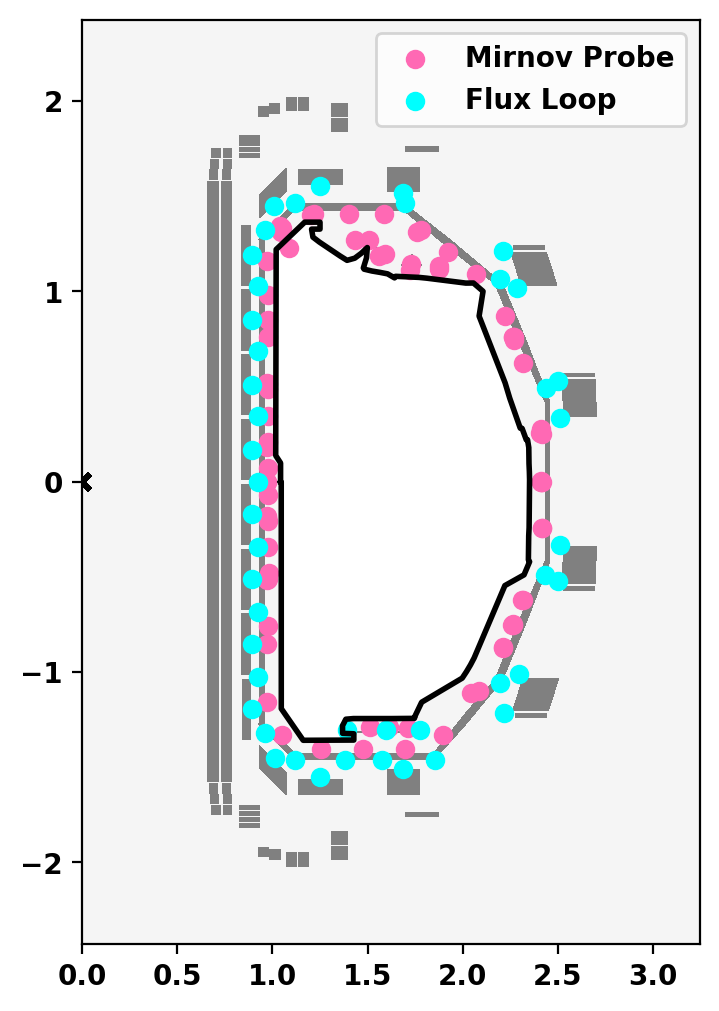

In [8]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,limiter_color='k')
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_constraints(fig, ax)

def plot_sensors(sensors, label, color):
    r_coords = [s[0] for _,s in sensors.items()]
    z_coords = [s[1] for _,s in sensors.items()]
    ax.scatter(x=r_coords, y=z_coords, label=label, color=color)

plot_sensors(mag_sensors, label="Mirnov Probe", color='hotpink')
plot_sensors(flux_loops, label="Flux Loop", color='cyan')

ax.legend()
plt.show()

### Load Shot Data from DIII-D
Here we load data from a DIII-D k file representing a shot at a given point in time. This contains measurements of values from the Mirnov probes and flux loops in `machine_dict`.

In [9]:
probes_dict, loops_dict, e_coil_dict, f_coil_dict, _ = read_kfile('k'+shot_tag, machine_dict, e_coil_names, f_coil_names)

## Profiles

Here we define profiles for the FF' and P' terms in the Grad-Shafranov equation. The profiles are defined using a combination of experimental profiles from the gEQDSK file and a supergaussian test function located in the SOL region. The supergaussian is nonphysical and serves only to demonstrate the effects of including current/pressure gradietns in the SOL region.

Toggle the `f_SOL` flag to turn SOL currents on and off, and toggle the `f_SOL_sign` function (plus or minus 1) to change the sign of the profiles.

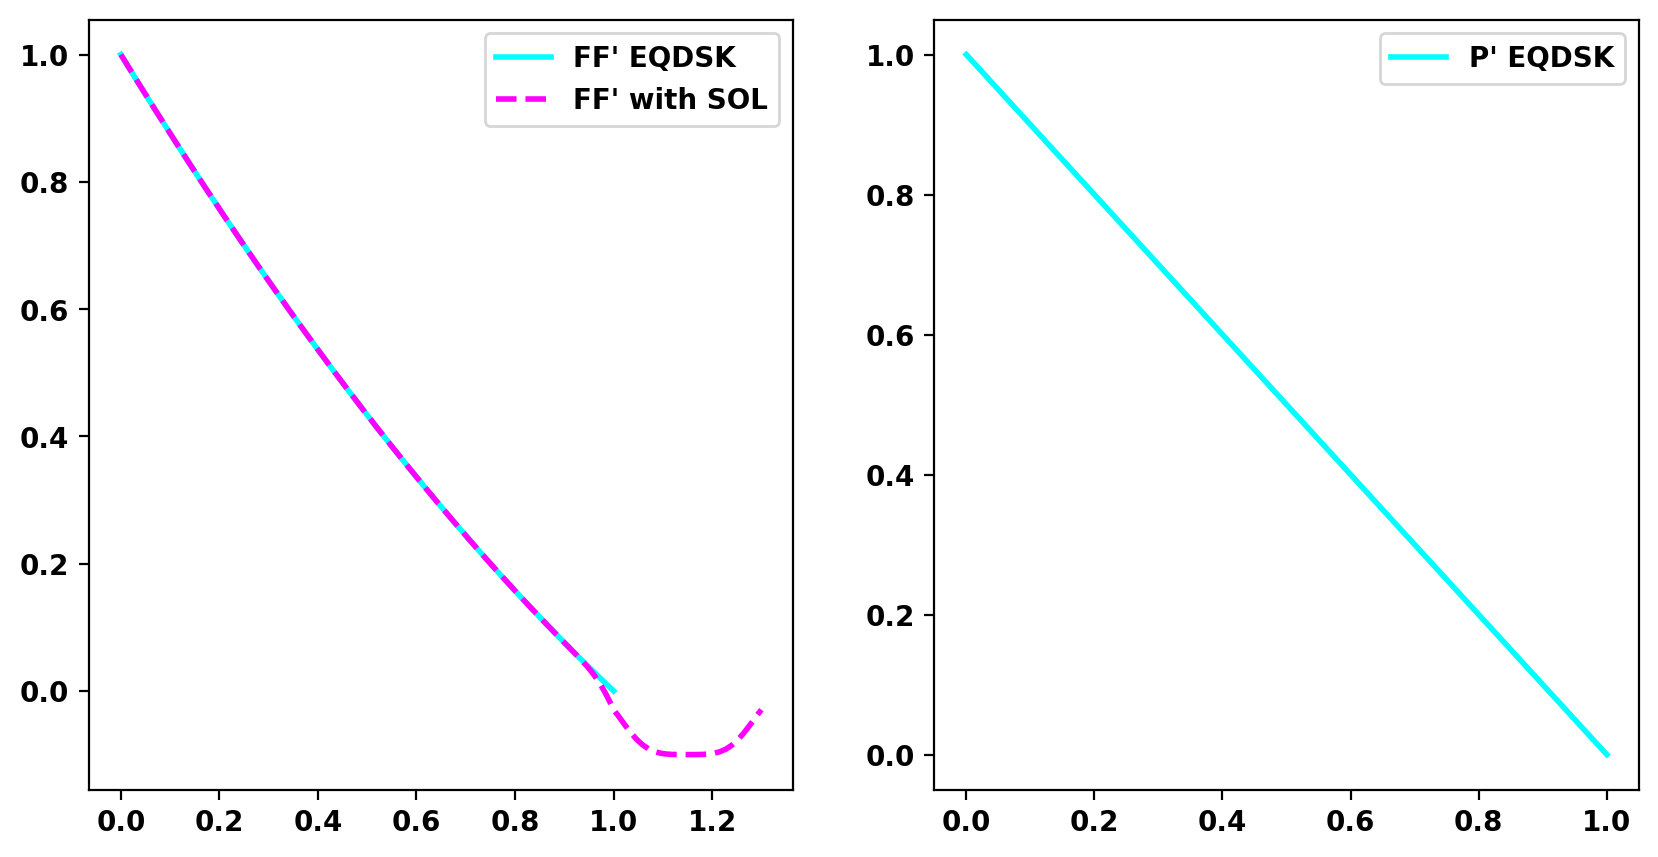

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ffprim = eqdsk['ffprim']
pprime = eqdsk['pprime']

eqdsk_aug = read_eqdsk('eqdsk_wsolcurrents.dat')
ffprim_aug = eqdsk_aug['ffprim']

ffprim -= ffprim[-1]
ffprim = ffprim / ffprim[0]

ffprim_aug -= ffprim_aug[-1]
ffprim_aug = ffprim_aug / ffprim_aug[0]

pprime -= pprime[-1]
pprime = pprime / pprime[0]

x = np.linspace(0.0, 1.0, len(ffprim))
x_aug = np.linspace(0.0, 1.0, len(ffprim_aug))

ax[0].plot(x, ffprim, label='FF\' EQDSK', color='cyan')
ax[1].plot(x, pprime, label='P\' EQDSK', color='cyan')

f_SOL = True
if f_SOL:
    x_sol = np.linspace(1.01, 1.3, 25)
    x_ffp = np.append(x, x_sol)
    ffprim = np.append(ffprim, len(x_sol) * [0.0]) 

    # def supergaussian(psi_n, centr, std=0.05):
    #     return np.exp(-(psi_n - centr) ** 4 / (2 * std**4))

    # ffp_bump = f_SOL_sign * 0.1 * supergaussian(x_ffp, 1.15, std=0.12)
    # ffprim += ffp_bump

ax[0].plot(x_aug, ffprim_aug, label='FF\' AUG', linestyle='--', color='magenta')

ax[0].legend()
ax[1].legend()
plt.show()

mygs.set_profiles(ffp_prof={'type': 'linterp', 'y': ffprim, 'x': x_ffp},pp_prof={'type': 'linterp', 'y': pprime, 'x': x}, f_SOL=f_SOL)


## Set LCFS and X Points
Here we extract the separatrix coordinates from the gEQDSK file as well as known x-points for the equilibrium and assign them to the TokaMaker GS object.

In [11]:
lcfs = eqdsk['rzout']
x_pts = np.array([[1.07414162, 1.14583397]])
lcfs = np.vstack((lcfs,x_pts))
mygs.set_isoflux_constraints(lcfs, weights = 1e3 * np.ones_like(lcfs[:,0]))
mygs.set_saddle_constraints(x_pts)

## Compute starting equilibrium

We can now compute a free-boundary equilibrium using the previously defined constraints. Note that before running a calculation for the first time we must initialize the flux function $\psi$, which can be done using init_psi(). We also define the E and F coil currents using information from the k-file. This subroutine initializes the flux using the specified Ip_target from above, which is evenly distributed over the entire plasma region or only with a boundary defined using a center point (R,Z), minor radius (a), and elongation and triangularity. Coil currents are also initialized at this point using the constraints above and this uniform plasma current initialization.

The \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.solve "solve()" method is then called to compute a self-consitent Grad-Shafranov equilibrium. If the result variable (`err_flag`) is zero then the solution has converged to the desired tolerance ($10^{-6}$ by default).

In [12]:
##### Add plasma current and flux loop constraints
Ip_target=abs(eqdsk['ip'])
P0_target=eqdsk['pres'][0]
mygs.set_targets(Ip=Ip_target, pax=P0_target)

target_currents = {}
target_errs = {}

for key in e_coil_dict:
    if e_coil_dict[key][1] == 0:
        continue
    target_currents[key] = e_coil_dict[key][0]
    target_errs[key] = abs(e_coil_dict[key][1])

for key in f_coil_dict:
    if f_coil_dict[key][1] == 0:
        continue
    target_currents[key] = f_coil_dict[key][0] / machine_dict['FCOIL'][key][4]
    target_errs[key] = abs(f_coil_dict[key][1] / machine_dict['FCOIL'][key][4])

# Set coil regularization to weakly track measured coil currents
regularization_terms = []
for key in e_coil_dict:
    if e_coil_dict[key][1] == 0:
        continue
    regularization_terms.append(mygs.coil_reg_term({key: 1.0},
                                                   target=target_currents[key],
                                                   weight=1.0E1))
for key in f_coil_dict:
    if f_coil_dict[key][1] == 0:
            continue
    regularization_terms.append(mygs.coil_reg_term({key: 1.0},
                                                   target=target_currents[key],
                                                   weight=1.0E2))

# Set zero target current and small weight on virtual VSC to allow up-down adjustment
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-2))

# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)

# Initial equilibrium with very rough guess
R0 = eqdsk['rcentr']
Z0 = 0.0
a = 0.6
kappa = 1.13
delta = .1

err_flag = mygs.init_psi(R0, Z0, a, kappa, delta)

# Compute initial equilibrium
mygs.settings.maxits=1000
mygs.update_settings()
mygs.solve()

Starting non-linear GS solver
     1  4.4873E+00  1.0007E+00  2.1784E-02  1.7173E+00 -1.9518E-03  1.9152E+02
     2  6.7396E+00  7.8027E-01  6.5753E-03  1.7127E+00 -1.8001E-02 -6.3650E+01
     3  7.4494E+00  7.2367E-01  2.6592E-03  1.7089E+00 -1.8169E-02 -1.5282E+02
     4  7.6966E+00  7.0424E-01  1.1087E-03  1.7066E+00 -1.8240E-02 -1.8583E+02
     5  7.7844E+00  6.9740E-01  4.8459E-04  1.7053E+00 -1.8267E-02 -1.9840E+02
     6  7.8151E+00  6.9499E-01  2.2465E-04  1.7046E+00 -1.8277E-02 -2.0339E+02
     7  7.8254E+00  6.9416E-01  1.0920E-04  1.7042E+00 -1.8279E-02 -2.0546E+02
     8  7.8286E+00  6.9388E-01  5.4422E-05  1.7040E+00 -1.8279E-02 -2.0634E+02
     9  7.8293E+00  6.9380E-01  2.7410E-05  1.7039E+00 -1.8278E-02 -2.0673E+02
    10  7.8294E+00  6.9378E-01  1.3835E-05  1.7039E+00 -1.8277E-02 -2.0690E+02
    11  7.8293E+00  6.9378E-01  6.9754E-06  1.7039E+00 -1.8276E-02 -2.0698E+02
    12  7.8292E+00  6.9379E-01  3.5104E-06  1.7039E+00 -1.8275E-02 -2.0702E+02
    13  7.8291E+00  6.

## Plot starting equilibrium
Flux surfaces of the computed equilibrium can be plotted using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_psi "plot_psi()" method. The additional plotting methods \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_machine "plot_machine()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_constraints "plot_constraints()" are also used to show context and other information. Each method has a large number of optional arguments for formatting and other options.

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.7809E+06
  Current Centroid [m]    =    1.636 -0.006
  Magnetic Axis [m]       =    1.704 -0.018
  Elongation              =    1.876 (U:  1.938, L:  1.814)
  Triangularity           =    0.804 (U:  0.948, L:  0.660)
  Plasma Volume [m^3]     =   19.160
  q_0, q_95               =   -0.802 -3.605
  Plasma Pressure [Pa]    =   Axis:  1.2789E+05, Peak:  1.2789E+05
  Stored Energy [J]       =    8.6728E+05
  <Beta_pol> [%]          =   47.4654
  <Beta_tor> [%]          =    1.6232
  <Beta_n>   [%]          =    1.1593
  Diamagnetic flux [Wb]   =   -4.6948E-02
  Toroidal flux [Wb]      =   -4.6414E+00
  l_i                     =    1.3781


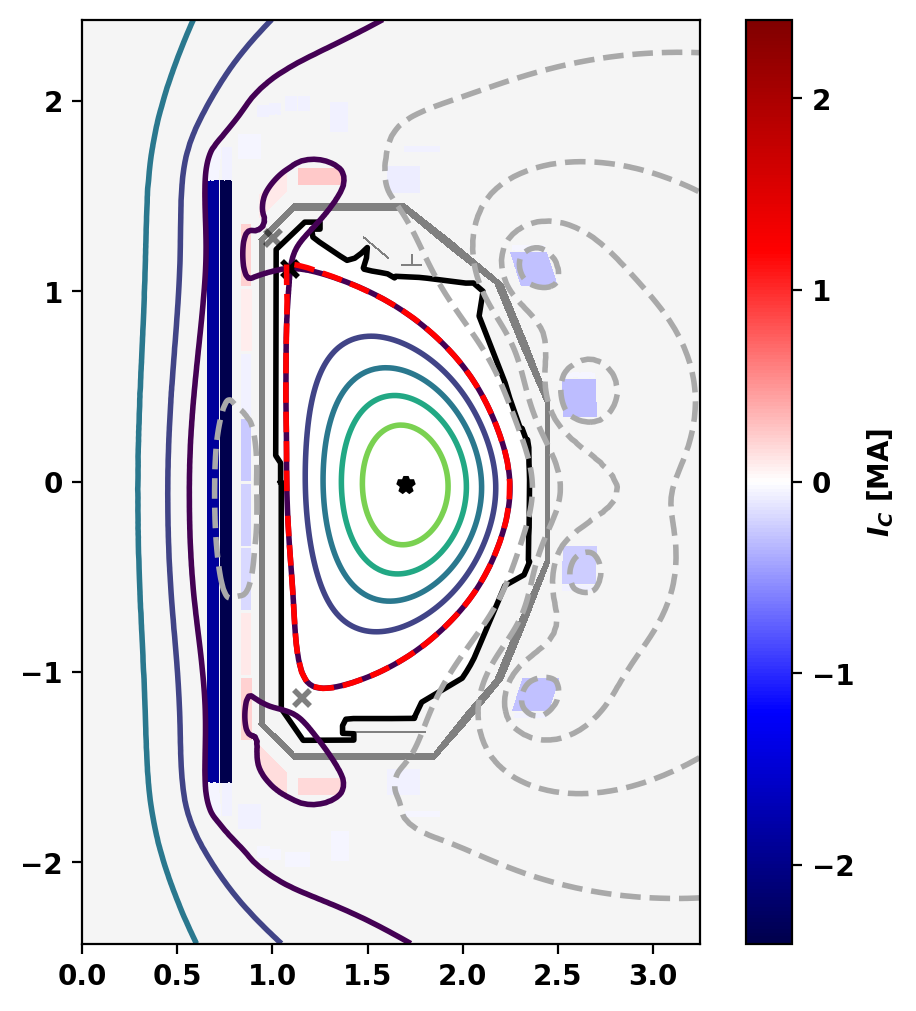

In [13]:
psi_eq = mygs.get_psi()
mygs.print_info()

fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,normalized=True,plasma_nlevels=6,vacuum_nlevels=5)
_ = ax.plot(eqdsk['rzout'][:,0], eqdsk['rzout'][:,1],'r--')

plt.show()

### Print equilibrium information and coil currents

Basic parameters can be displayed using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info()" method. For access to these quantities as variables instead the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_stats "get_stats()" can be used.

The final coil currents can also be retrieved using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_coil_currents "get_coil_currents()" method, which are all within the approximate coil limits imposed above.

In [14]:
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    if key not in target_currents:
        continue
    current_adj = current
    measured_currt = target_currents[key]
    pct_diff = 100.0 * (current_adj-measured_currt)/measured_currt
    print('  {0:10} {1:11.3F} {2:11.3F} {3:10.2F}%'.format(key+":", current_adj/1.E3, measured_currt/1.E3, pct_diff))

Coil Currents [kA]:
  F1A:            -4.410      -3.510      25.65%
  F2A:            -1.178      -1.508     -21.89%
  F3A:             1.599      -0.047   -3532.71%
  F4A:             3.870       3.113      24.34%
  F5A:             1.817       3.186     -42.98%
  F6A:            -5.577      -4.847      15.07%
  F7A:            -5.155      -5.705      -9.64%
  F8A:             4.241       3.198      32.63%
  F9A:            -1.618      -4.054     -60.09%
  F1B:            -3.847      -2.719      41.49%
  F2B:            -3.197      -3.096       3.27%
  F3B:             1.719      -0.050   -3559.59%
  F4B:             3.627       2.932      23.71%
  F5B:             2.776       2.679       3.62%
  F6B:            -4.214      -3.925       7.34%
  F7B:            -5.302      -5.927     -10.55%
  F8B:             3.159       3.905     -19.09%
  F9B:            -1.194      -4.044     -70.49%


## Plot Measured vs. Computed SE Values

### Plot SE Currents
Here we plot currents from the solved equilibrium vs. the input currents.

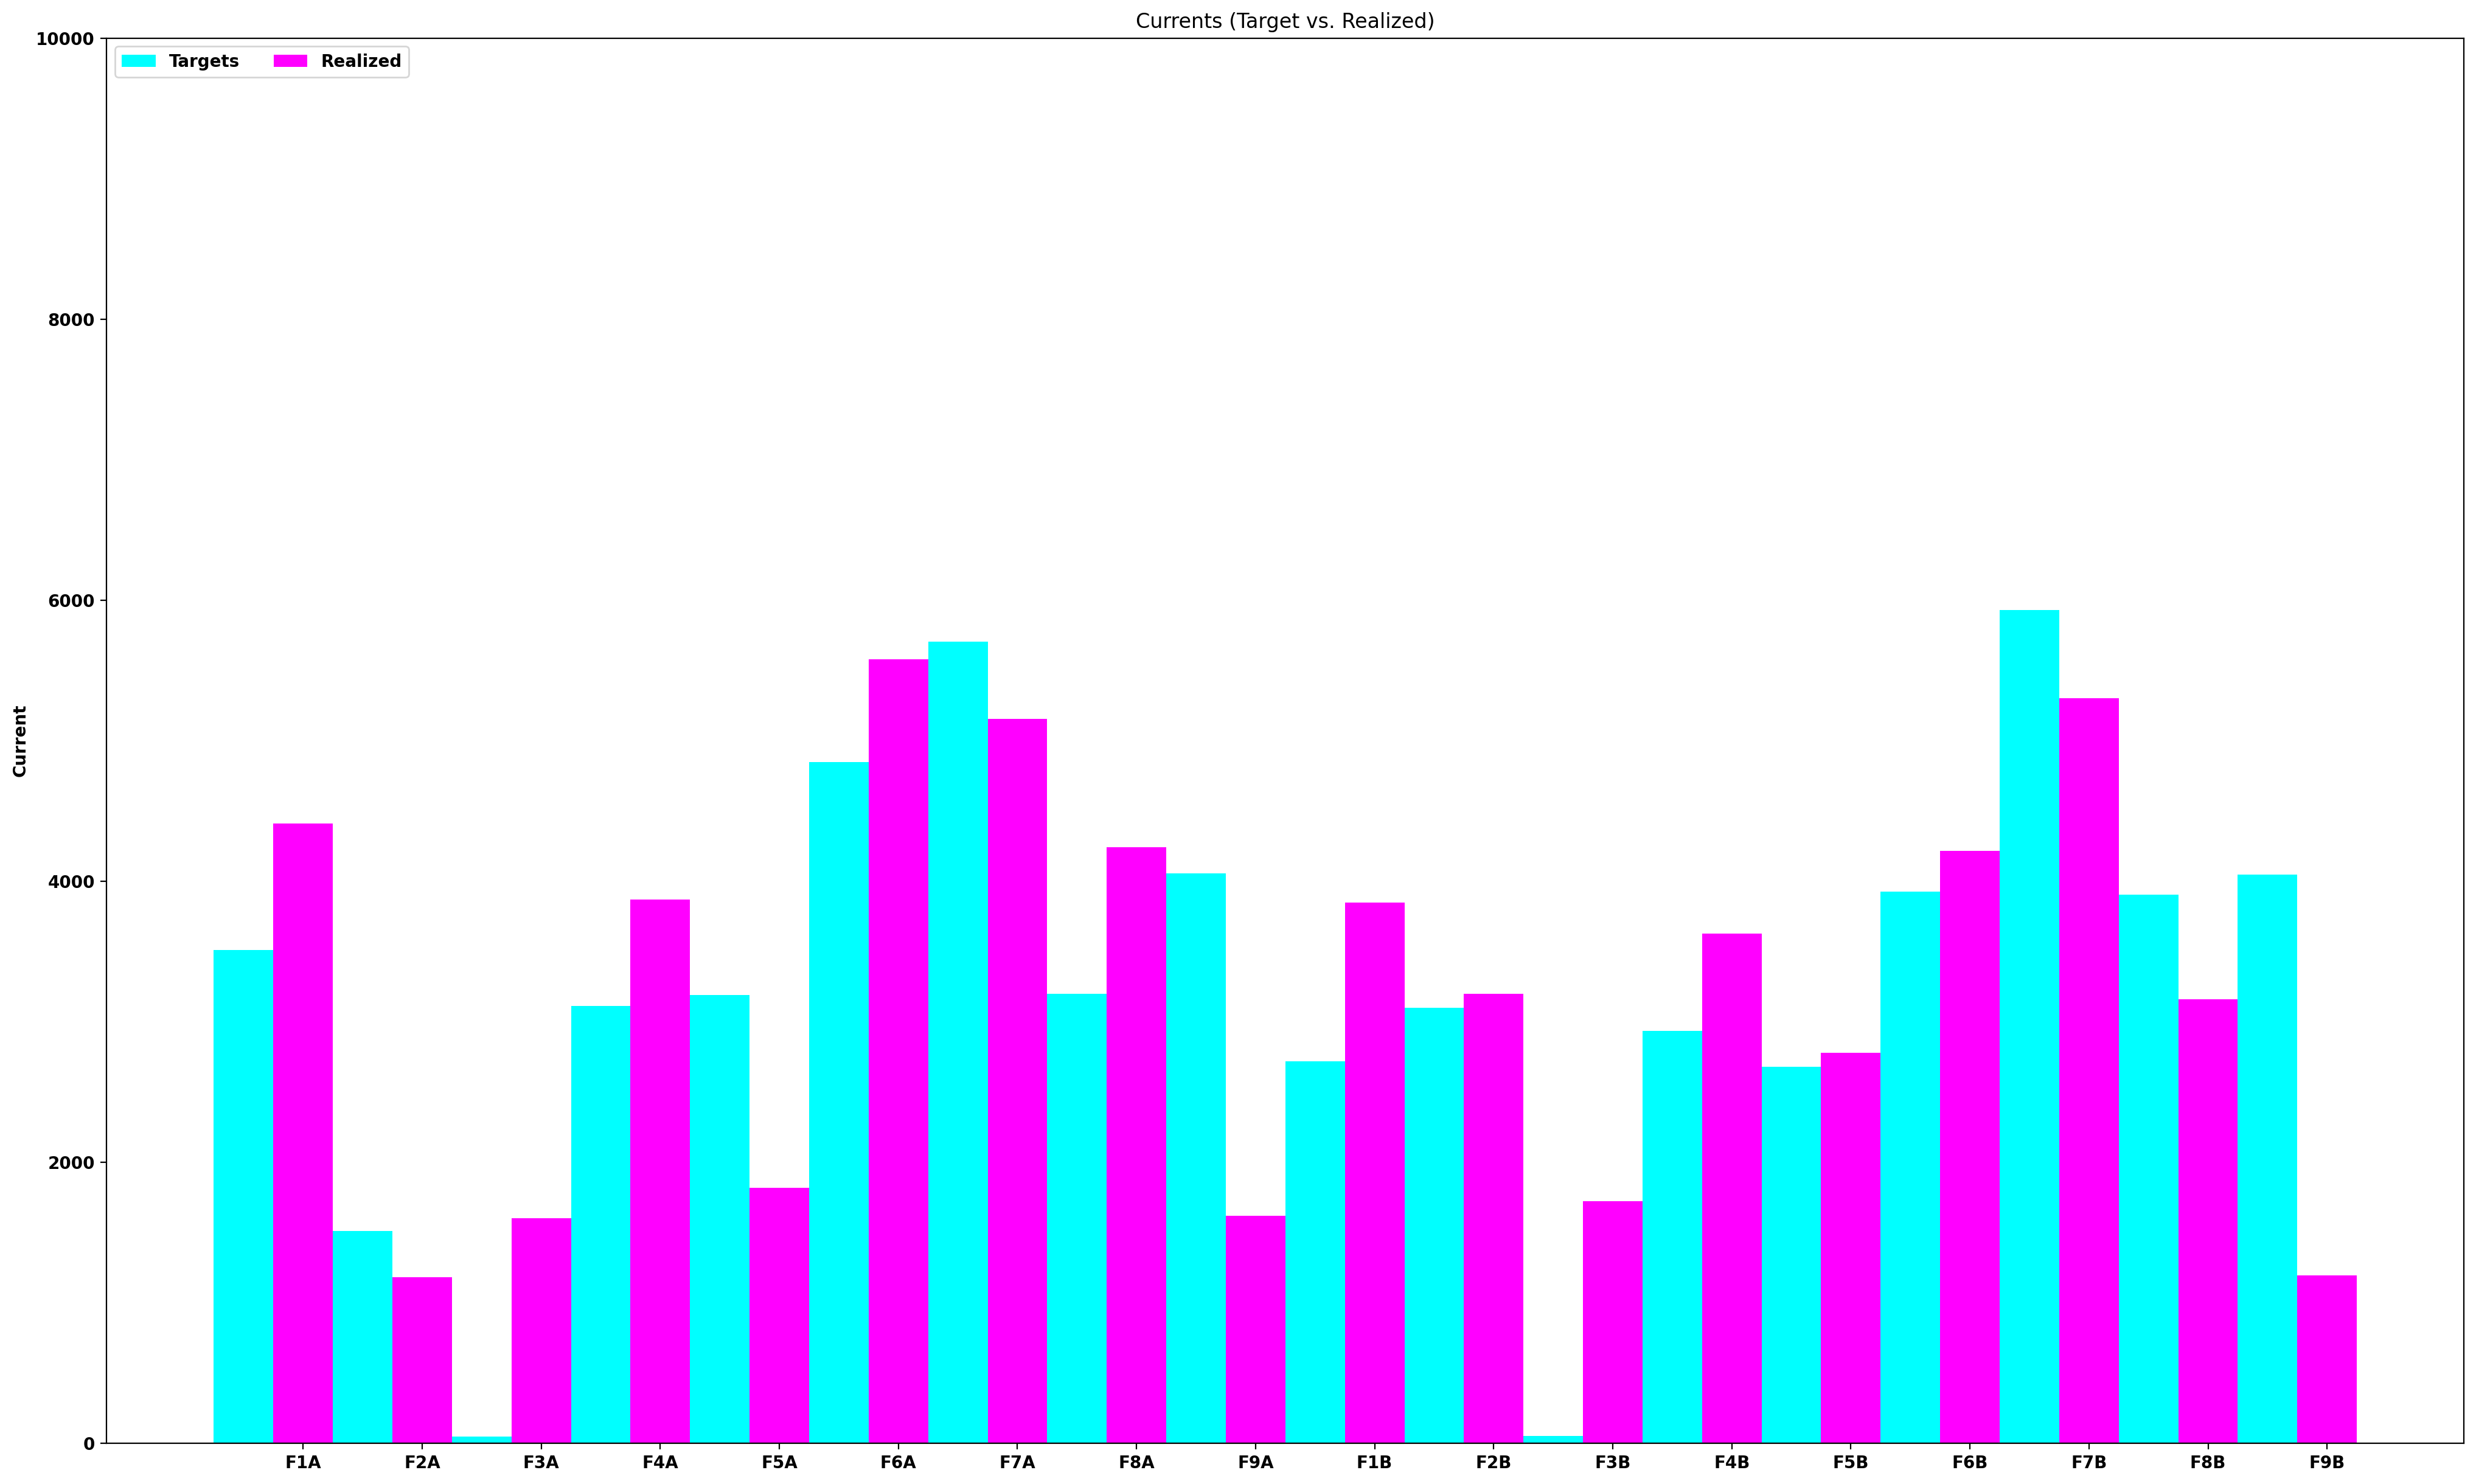

In [15]:
plot_colors = {'Targets': 'cyan', 'Realized': 'magenta', 'Error': 'blue'}

def plot_currents():
    coil_currents, _ = mygs.get_coil_currents()
    coil_names = [key for key in coil_currents if key in target_currents]
    coil_info = {'Targets': [abs(target_currents[key]) for key in coil_names if key in target_currents],
                 'Realized': [abs(coil_currents[key]) for key in coil_names if key in target_currents]}
    coil_err = np.array([np.abs(target_errs[key]) for key in coil_names if key in target_currents])

    x = np.arange(len(coil_names))  # the label locations
    width = 0.5  # the width of the bars
    multiplier = 0
    
    _, ax = plt.subplots(figsize=(25, 15))
    
    for attribute, measurement in coil_info.items():
        offset = width * multiplier
        ax.bar(x + offset, measurement, width, label=attribute, color=plot_colors[attribute])
        multiplier += 1
    
    ax.set_ylabel('Current')
    ax.set_title('Currents (Target vs. Realized)')
    ax.set_xticks(x + width, coil_names)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.0E4)

    plt.show()

plot_currents()

### Perform Reconstruction
Now we can use the Mirnov probes and flux loops measurements extracted from the k-file to reconstruct an equilibrium. We feed these values into a reconstruction object to attempt to reconstruct the previous equilibrium from the diagnostics.

In [16]:
myrecon = reconstruction(mygs)

def convert_Mirnov_coordinates(sensor):
    R, z, angle = sensor
    position = np.array([R, z])

    angle_rads = angle * np.pi / 180
    orientation = np.array([np.cos(angle_rads), 0, np.sin(angle_rads)])
    return position, orientation

B_vals = [probes_dict[key][0] for key in mag_sensors if key in probes_dict]
B_mean = np.mean(np.positive(B_vals))
mirnov_names = []

for key, mag in mag_sensors.items():
    if probes_dict[key][1] == 0:
        print("{} not selected.".format(key))
        continue
    position, orientation = convert_Mirnov_coordinates(mag)
    mirnov_names.append(key)
    B_meas, _ = probes_dict[key]
    myrecon.add_Mirnov(position, orientation, B_meas, err=0.1*max(B_mean, abs(B_meas)))

flux_locs = []
flux_vals = []

psi_vals = [loops_dict[key][0] for key in flux_loops if key in loops_dict]
psi_mean = np.mean(np.positive(psi_vals))

flux_names = []

for key, fl in flux_loops.items():
    if loops_dict[key][1] == 0:
        print("{} not selected.".format(key))
        continue
    flux_names.append(key)
    B_tmp, _ = loops_dict[key]
    flux_locs.append(fl)
    flux_vals.append(B_tmp)
    psi_val = B_tmp*2.0*np.pi
    myrecon.add_flux_loop(fl, psi_val, err=0.1*(max(psi_mean, abs(psi_val))))

# mygs.set_flux(np.array(flux_locs), np.array(flux_vals), weights=100*np.ones_like(flux_vals))

# Remove all shape constraints
mygs.set_isoflux(None)
mygs.set_flux(None,None)
mygs.set_saddles(None)

# Set initial position targets from current values
mygs.set_targets(R0=mygs.o_point[0],V0=mygs.o_point[1])

# Set Recon Plasma Current
myrecon.set_Ip(Ip_target, err=0.1*Ip_target)

# Set reconstruction settings
myrecon.settings.fitF = True
myrecon.settings.fitP = True
myrecon.settings.fit_Pscale = True
myrecon.settings.fit_FFPscale = False
myrecon.settings.fitR0 = False
myrecon.settings.fitZ0 = False
myrecon.settings.fixedCentering = False

# Perform reconstructions
mygs.settings.nl_tol=1.E-6
err_flag = myrecon.reconstruct()

MPI66M247 not selected.
MPI79A147 not selected.
MPI6NA132 not selected.
MPI7NB322 not selected.
DSL3U180 not selected.
MPI5U157 not selected.
MPI6U157 not selected.
MPI7U157 not selected.
DSL5U157 not selected.
DSL6U157 not selected.
MPI3L180 not selected.
PSF3A not selected.
PSF7NA not selected.
PSI34A not selected.
PSF6FB not selected.
PSI89FB not selected.
PSI2L not selected.

*** Loading fit constraints ***

Starting Fit:
  # of free parameters   =  536
  # of constraints       =  104

Function evaluation    1
  FFp_scale         =  7.829E+00
  P_scale           =  6.938E-01
  Z0_target         = -1.827E-02
  F_cofs            = -5.463E-02 -6.678E-02 -7.729E-02 -8.562E-02 -9.167E-02 -9.568E-02 -9.807E-02 -9.930E-02 -9.983E-02 -9.998E-02 -1.000E-01 -1.000E-01 -9.997E-02 -9.977E-02 -9.915E-02 -9.775E-02 -9.512E-02 -9.078E-02 -8.435E-02 -7.563E-02 -6.479E-02 -5.244E-02 -3.960E-02 -2.950E-02 -2.298E-02 -1.666E-02 -1.058E-02 -4.755E-03  7.972E-04  6.071E-03  1.107E-02  1.579E-02  2.026E

/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_82489/2597096143.py:46: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_82489/2597096143.py:47: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(None,None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_82489/2597096143.py:48: DeprecationWarning: `set_saddles()` is deprecated, use `set_saddle_constraints()` instead. This function will be removed in a future version.
  mygs.set_saddles(None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_82489/2597096143.py:51: DeprecationWarning: `V0` is deprecated, use `Z0` instead. This argument will be removed in a future version.
  mygs.set_targets(R0=mygs.o_point[0],V0=mygs.o_point[1])


  FFp_scale         =  7.829E+00
  P_scale           =  6.938E-01
  Z0_target         = -1.827E-02
  F_cofs            = -5.463E-02 -6.678E-02 -7.729E-02 -8.562E-02 -9.167E-02 -9.568E-02 -9.807E-02 -9.930E-02 -9.983E-02 -9.998E-02 -1.000E-01 -1.000E-01 -9.997E-02 -9.977E-02 -9.915E-02 -9.775E-02 -9.512E-02 -9.078E-02 -8.435E-02 -7.563E-02 -6.479E-02 -5.244E-02 -3.960E-02 -2.950E-02 -2.298E-02 -1.666E-02 -1.058E-02 -4.755E-03  7.972E-04  6.071E-03  1.107E-02  1.579E-02  2.026E-02  2.450E-02  2.851E-02  3.233E-02  3.598E-02  3.950E-02  4.289E-02  4.620E-02  4.943E-02  5.260E-02  5.573E-02  5.884E-02  6.193E-02  6.501E-02  6.808E-02  7.115E-02  7.423E-02  7.731E-02  8.039E-02  8.349E-02  8.659E-02  8.969E-02  9.281E-02  9.593E-02  9.907E-02  1.022E-01  1.054E-01  1.085E-01  1.117E-01  1.148E-01  1.180E-01  1.212E-01  1.244E-01  1.276E-01  1.308E-01  1.341E-01  1.373E-01  1.405E-01  1.438E-01  1.470E-01  1.503E-01  1.535E-01  1.568E-01  1.601E-01  1.634E-01  1.667E-01  1.700E-01  1.733E-01

### Print equilibrium information and coil currents
As above we use \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_coil_currents "get_coil_currents()" to display information on the final equilibrium.

In [17]:
mygs.print_info()

print()
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    if key not in target_currents:
        continue
    measured_currt = target_currents[key]
    pct_diff = 100.0 * (current-measured_currt)/measured_currt
    print('  {0:10} {1:11.3F} {2:11.3F} {3:10.2F}%'.format(key+":", current/1.E3, measured_currt/1.E3, pct_diff))

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.7810E+06
  Current Centroid [m]    =    1.635 -0.006
  Magnetic Axis [m]       =    1.704 -0.018
  Elongation              =    1.876 (U:  1.938, L:  1.814)
  Triangularity           =    0.804 (U:  0.948, L:  0.660)
  Plasma Volume [m^3]     =   19.162
  q_0, q_95               =   -0.801 -3.600
  Plasma Pressure [Pa]    =   Axis:  1.2790E+05, Peak:  1.2790E+05
  Stored Energy [J]       =    8.6732E+05
  <Beta_pol> [%]          =   47.4628
  <Beta_tor> [%]          =    1.6232
  <Beta_n>   [%]          =    1.1592
  Diamagnetic flux [Wb]   =   -4.0350E-02
  Toroidal flux [Wb]      =   -4.6351E+00
  l_i                     =    1.3781

Coil Currents [kA]:
  F1A:            -4.410      -3.510      25.65%
  F2A:            -1.178      -1.508     -21.89%
  F3A:             1.599      -0.047   -3532.71%
  F4A:             3.870       3.113      24.34%
  F5A:             1.817       3.186     -42

## Plot final reconstructed equilibrium
Here we plot the reconstruction separatrix (red) vs. the original separatrix from the gEQDSK file (cyan).

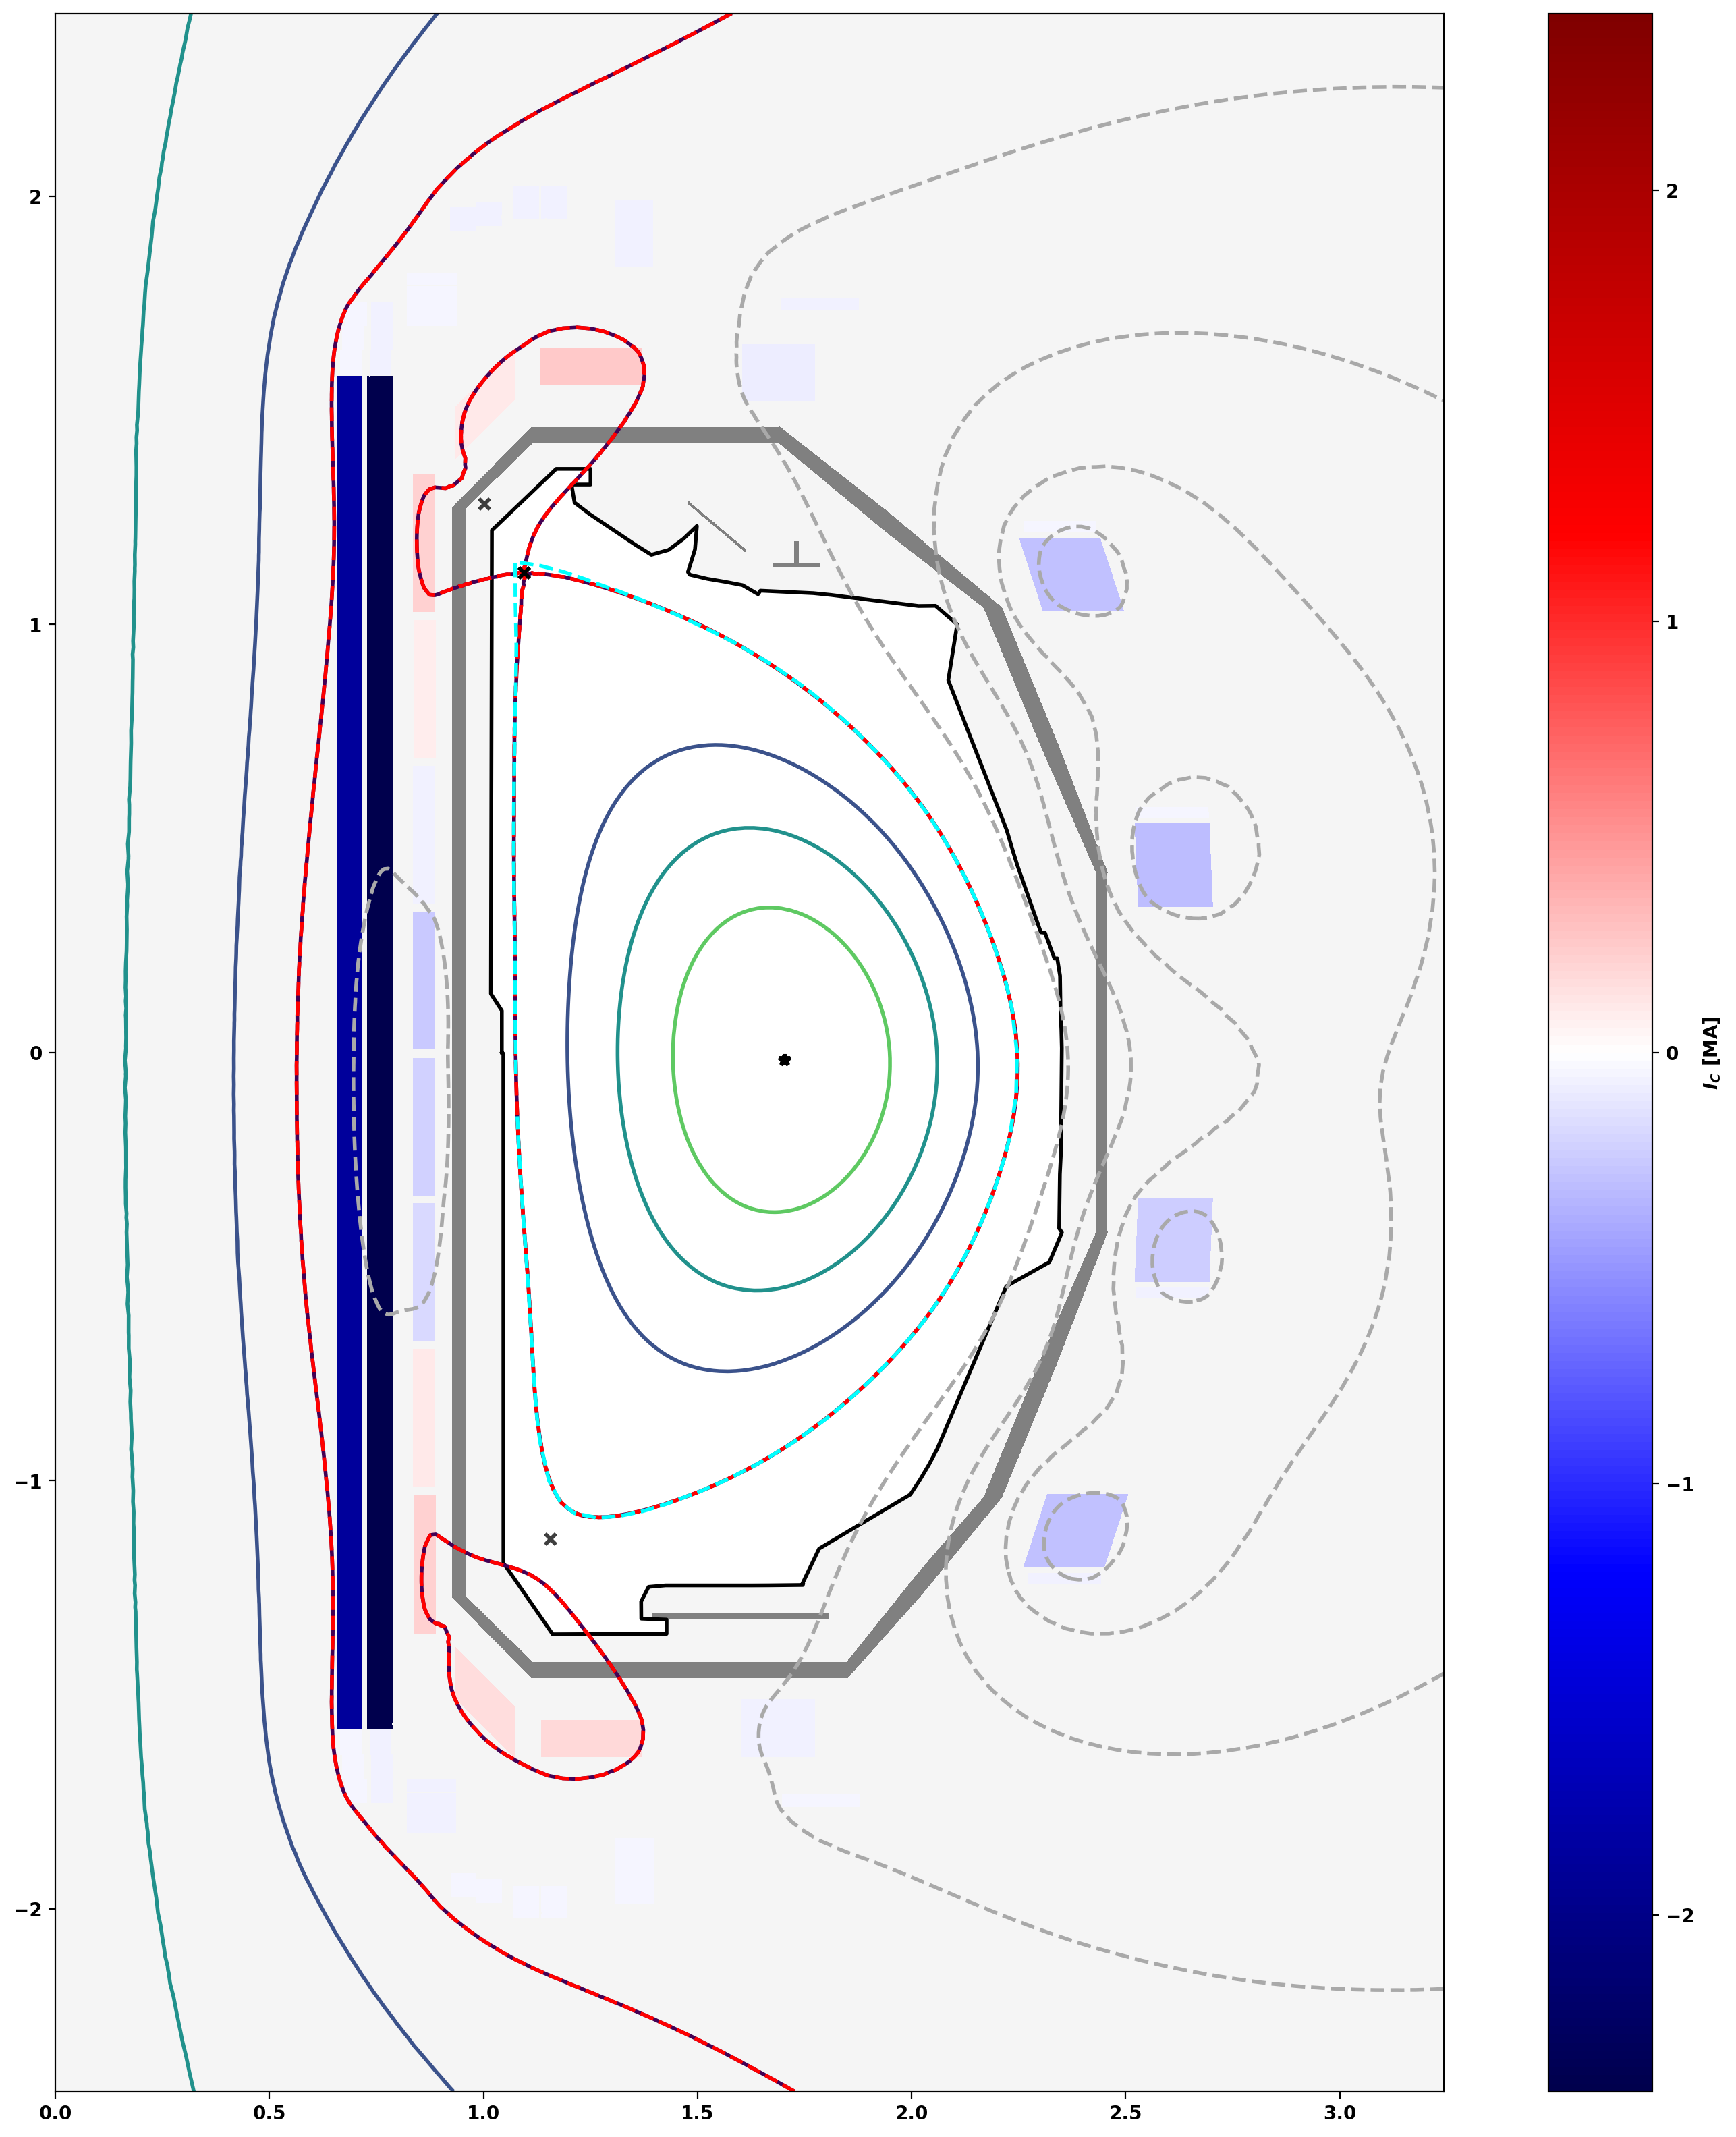

In [18]:
fig, ax = plt.subplots(1,1, figsize=(20,20))

# Plot Psi
psi_recons = mygs.get_psi()
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_psi(fig,ax,psi=psi_recons,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')

LCFS_eqdsk = eqdsk['rzout']
ax.plot(LCFS_eqdsk[:,0], LCFS_eqdsk[:,1], color='cyan', linestyle='--')

plt.show()

## Plot Current Density
We can now plot a heatmap of current density inside the DIII-D vessel using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_current_density "plot_current_density()".

Starting CG solver
     0  0.000000E+00  0.000000E+00  6.521838E-01
     1 -4.241671E+02  2.251978E+03  3.230682E-01  1.434597E-04
     2 -5.150676E+02  2.085673E+03  1.357804E-01  6.510147E-05
     3 -5.264767E+02  2.190208E+03  4.789785E-02  2.186909E-05
     4 -5.279117E+02  2.194957E+03  1.900024E-02  8.656315E-06
     5 -5.281573E+02  2.196850E+03  7.003442E-03  3.187947E-06
     6 -5.281848E+02  2.192173E+03  2.309276E-03  1.053419E-06
     7 -5.281882E+02  2.191656E+03  8.784831E-04  4.008307E-07
     8 -5.281887E+02  2.191354E+03  3.557578E-04  1.623461E-07
     9 -5.281888E+02  2.191279E+03  1.408671E-04  6.428533E-08
    10 -5.281888E+02  2.191327E+03  5.724162E-05  2.612190E-08
    20 -5.281888E+02  2.191361E+03  4.001205E-09  1.825899E-12


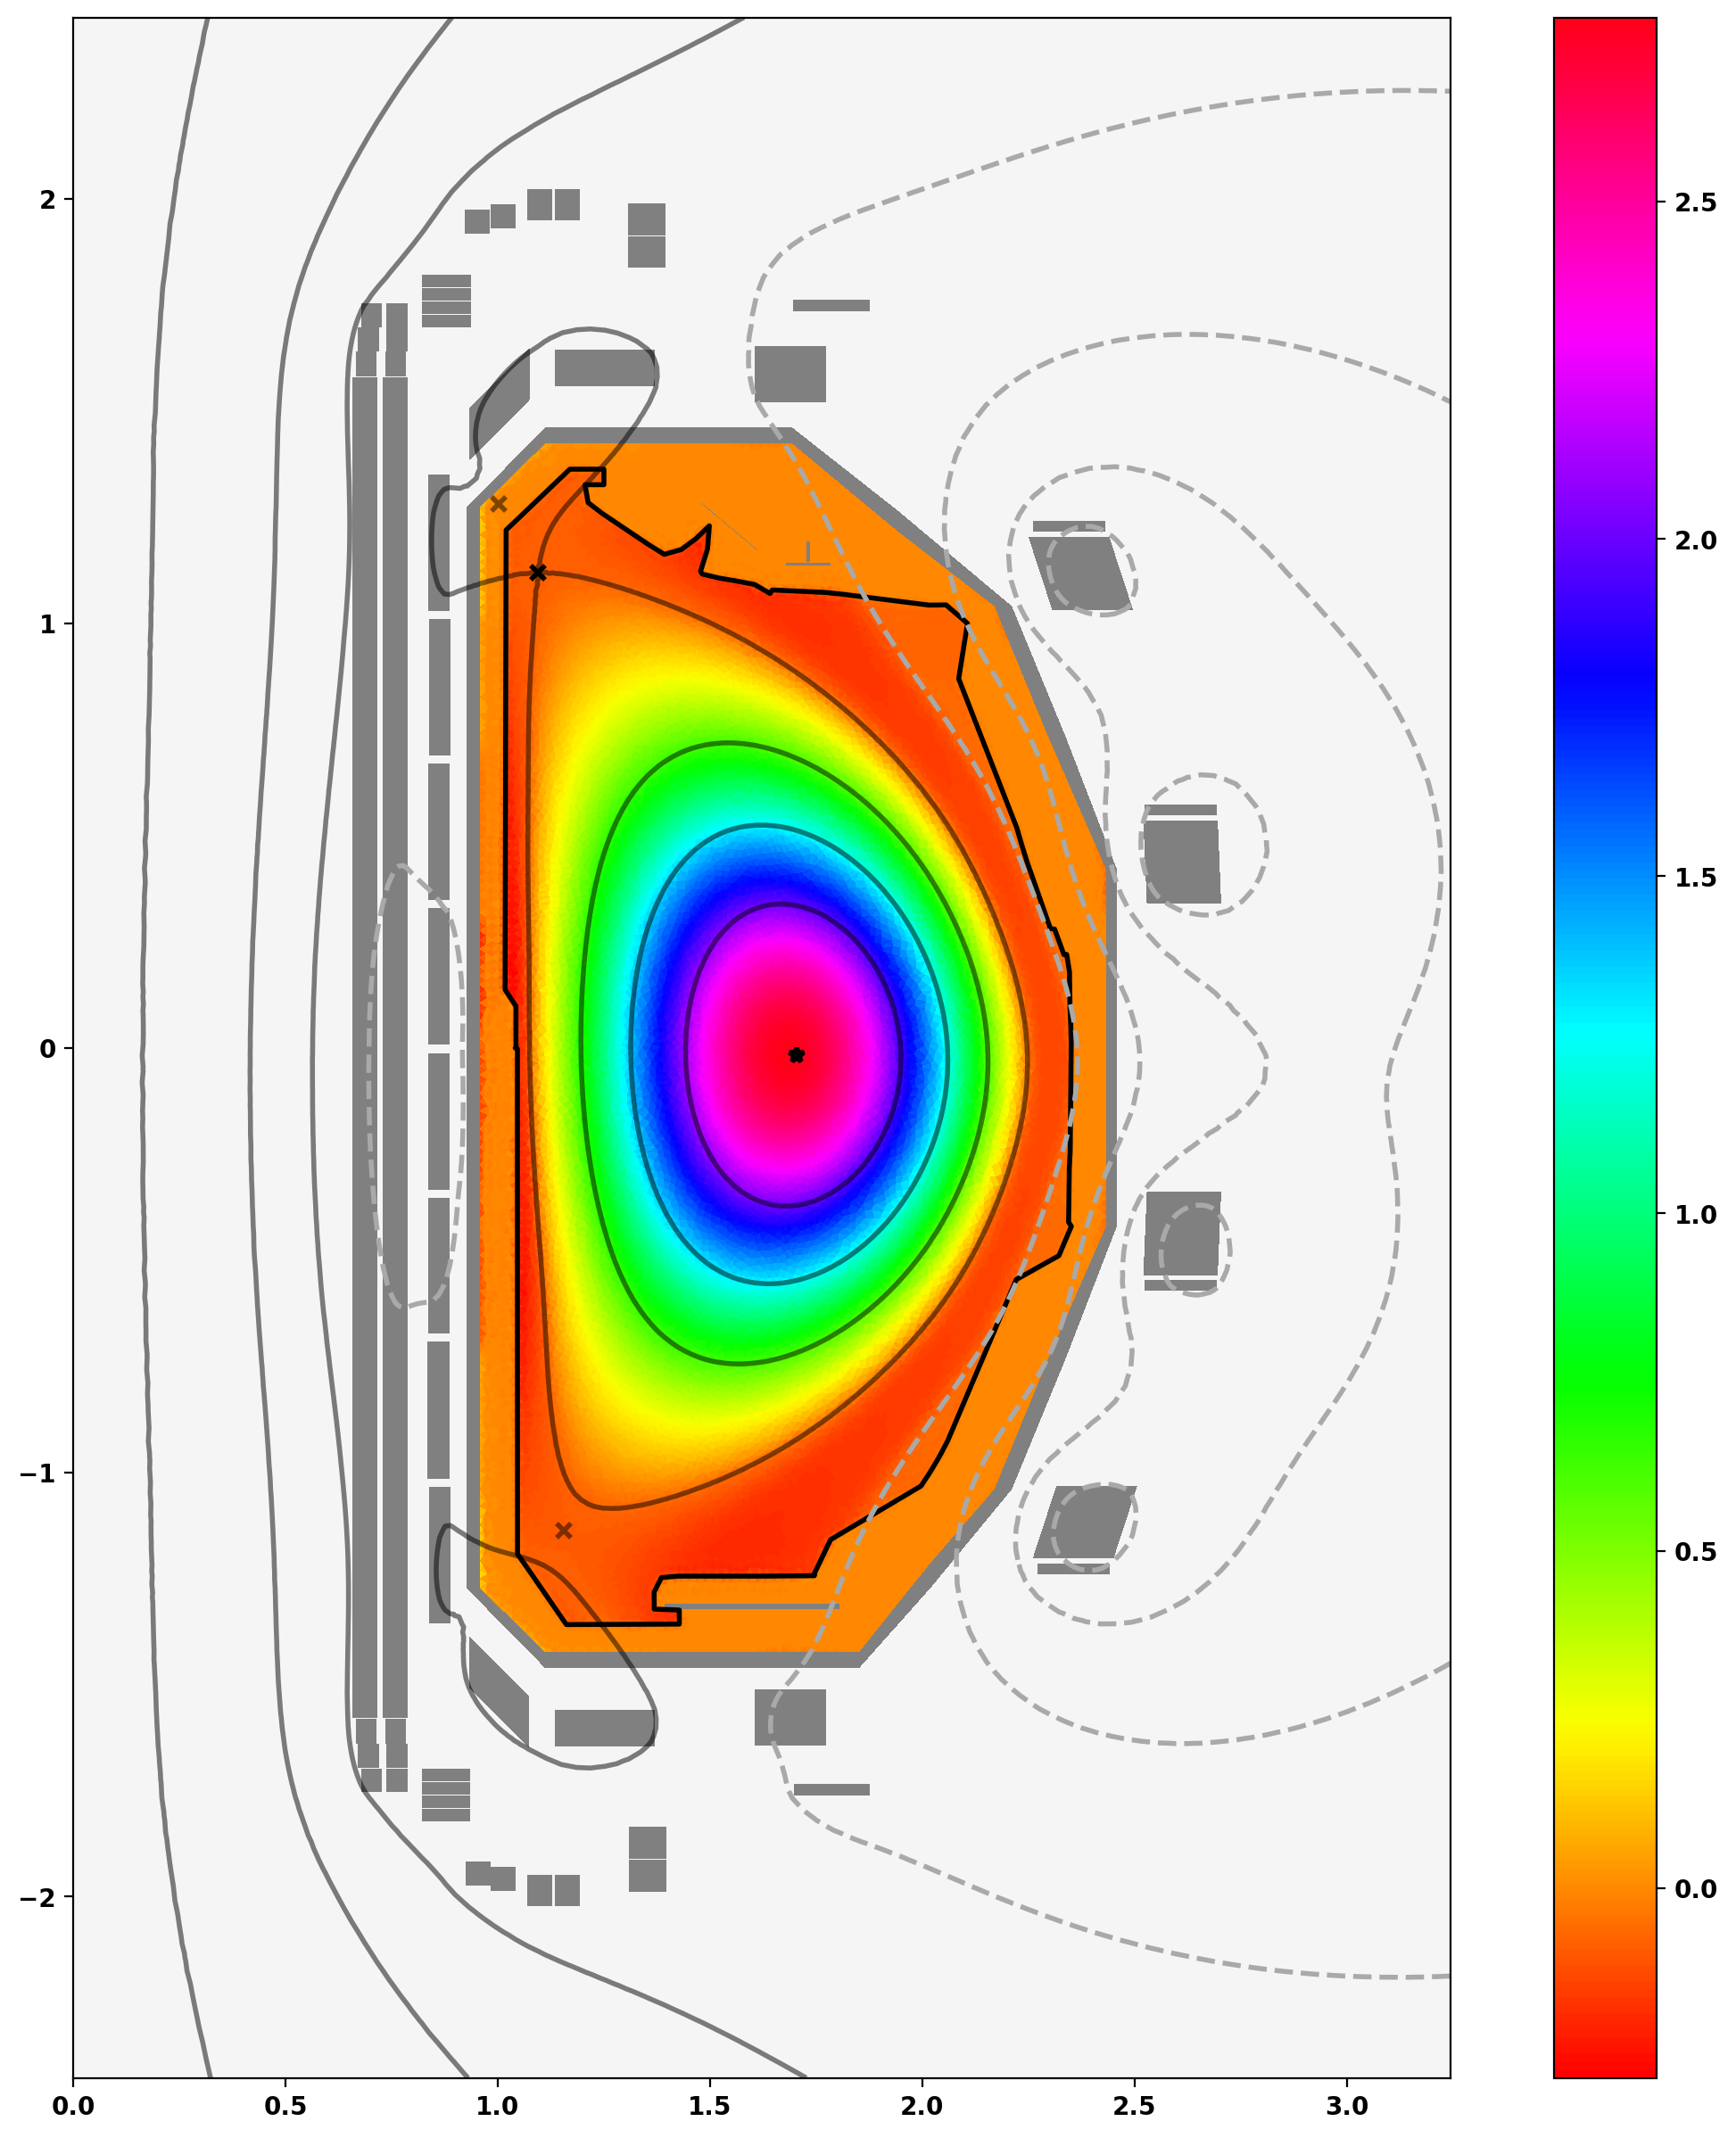

In [19]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1,1, figsize=(15,15))
cmap = ListedColormap([[0.0, 0.0, 0.0, 0.5]])

mygs.plot_machine(fig,ax,coil_clabel=None)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5, plasma_colormap=cmap)
mygs.plot_current_density(fig, ax, cmap='hsv')

# Show the plot
plt.show()

## Plot Current Density in Divertor Region
Here we provide a zoomed-in view of the previous plot, focusing on the divertor region.

Starting CG solver
     0  0.000000E+00  0.000000E+00  6.521838E-01
     1 -4.241671E+02  2.251978E+03  3.230682E-01  1.434597E-04
     2 -5.150676E+02  2.085673E+03  1.357804E-01  6.510147E-05
     3 -5.264767E+02  2.190208E+03  4.789785E-02  2.186909E-05
     4 -5.279117E+02  2.194957E+03  1.900024E-02  8.656315E-06
     5 -5.281573E+02  2.196850E+03  7.003442E-03  3.187947E-06
     6 -5.281848E+02  2.192173E+03  2.309276E-03  1.053419E-06
     7 -5.281882E+02  2.191656E+03  8.784831E-04  4.008307E-07
     8 -5.281887E+02  2.191354E+03  3.557578E-04  1.623461E-07
     9 -5.281888E+02  2.191279E+03  1.408671E-04  6.428533E-08
    10 -5.281888E+02  2.191327E+03  5.724162E-05  2.612190E-08
    20 -5.281888E+02  2.191361E+03  4.001205E-09  1.825899E-12


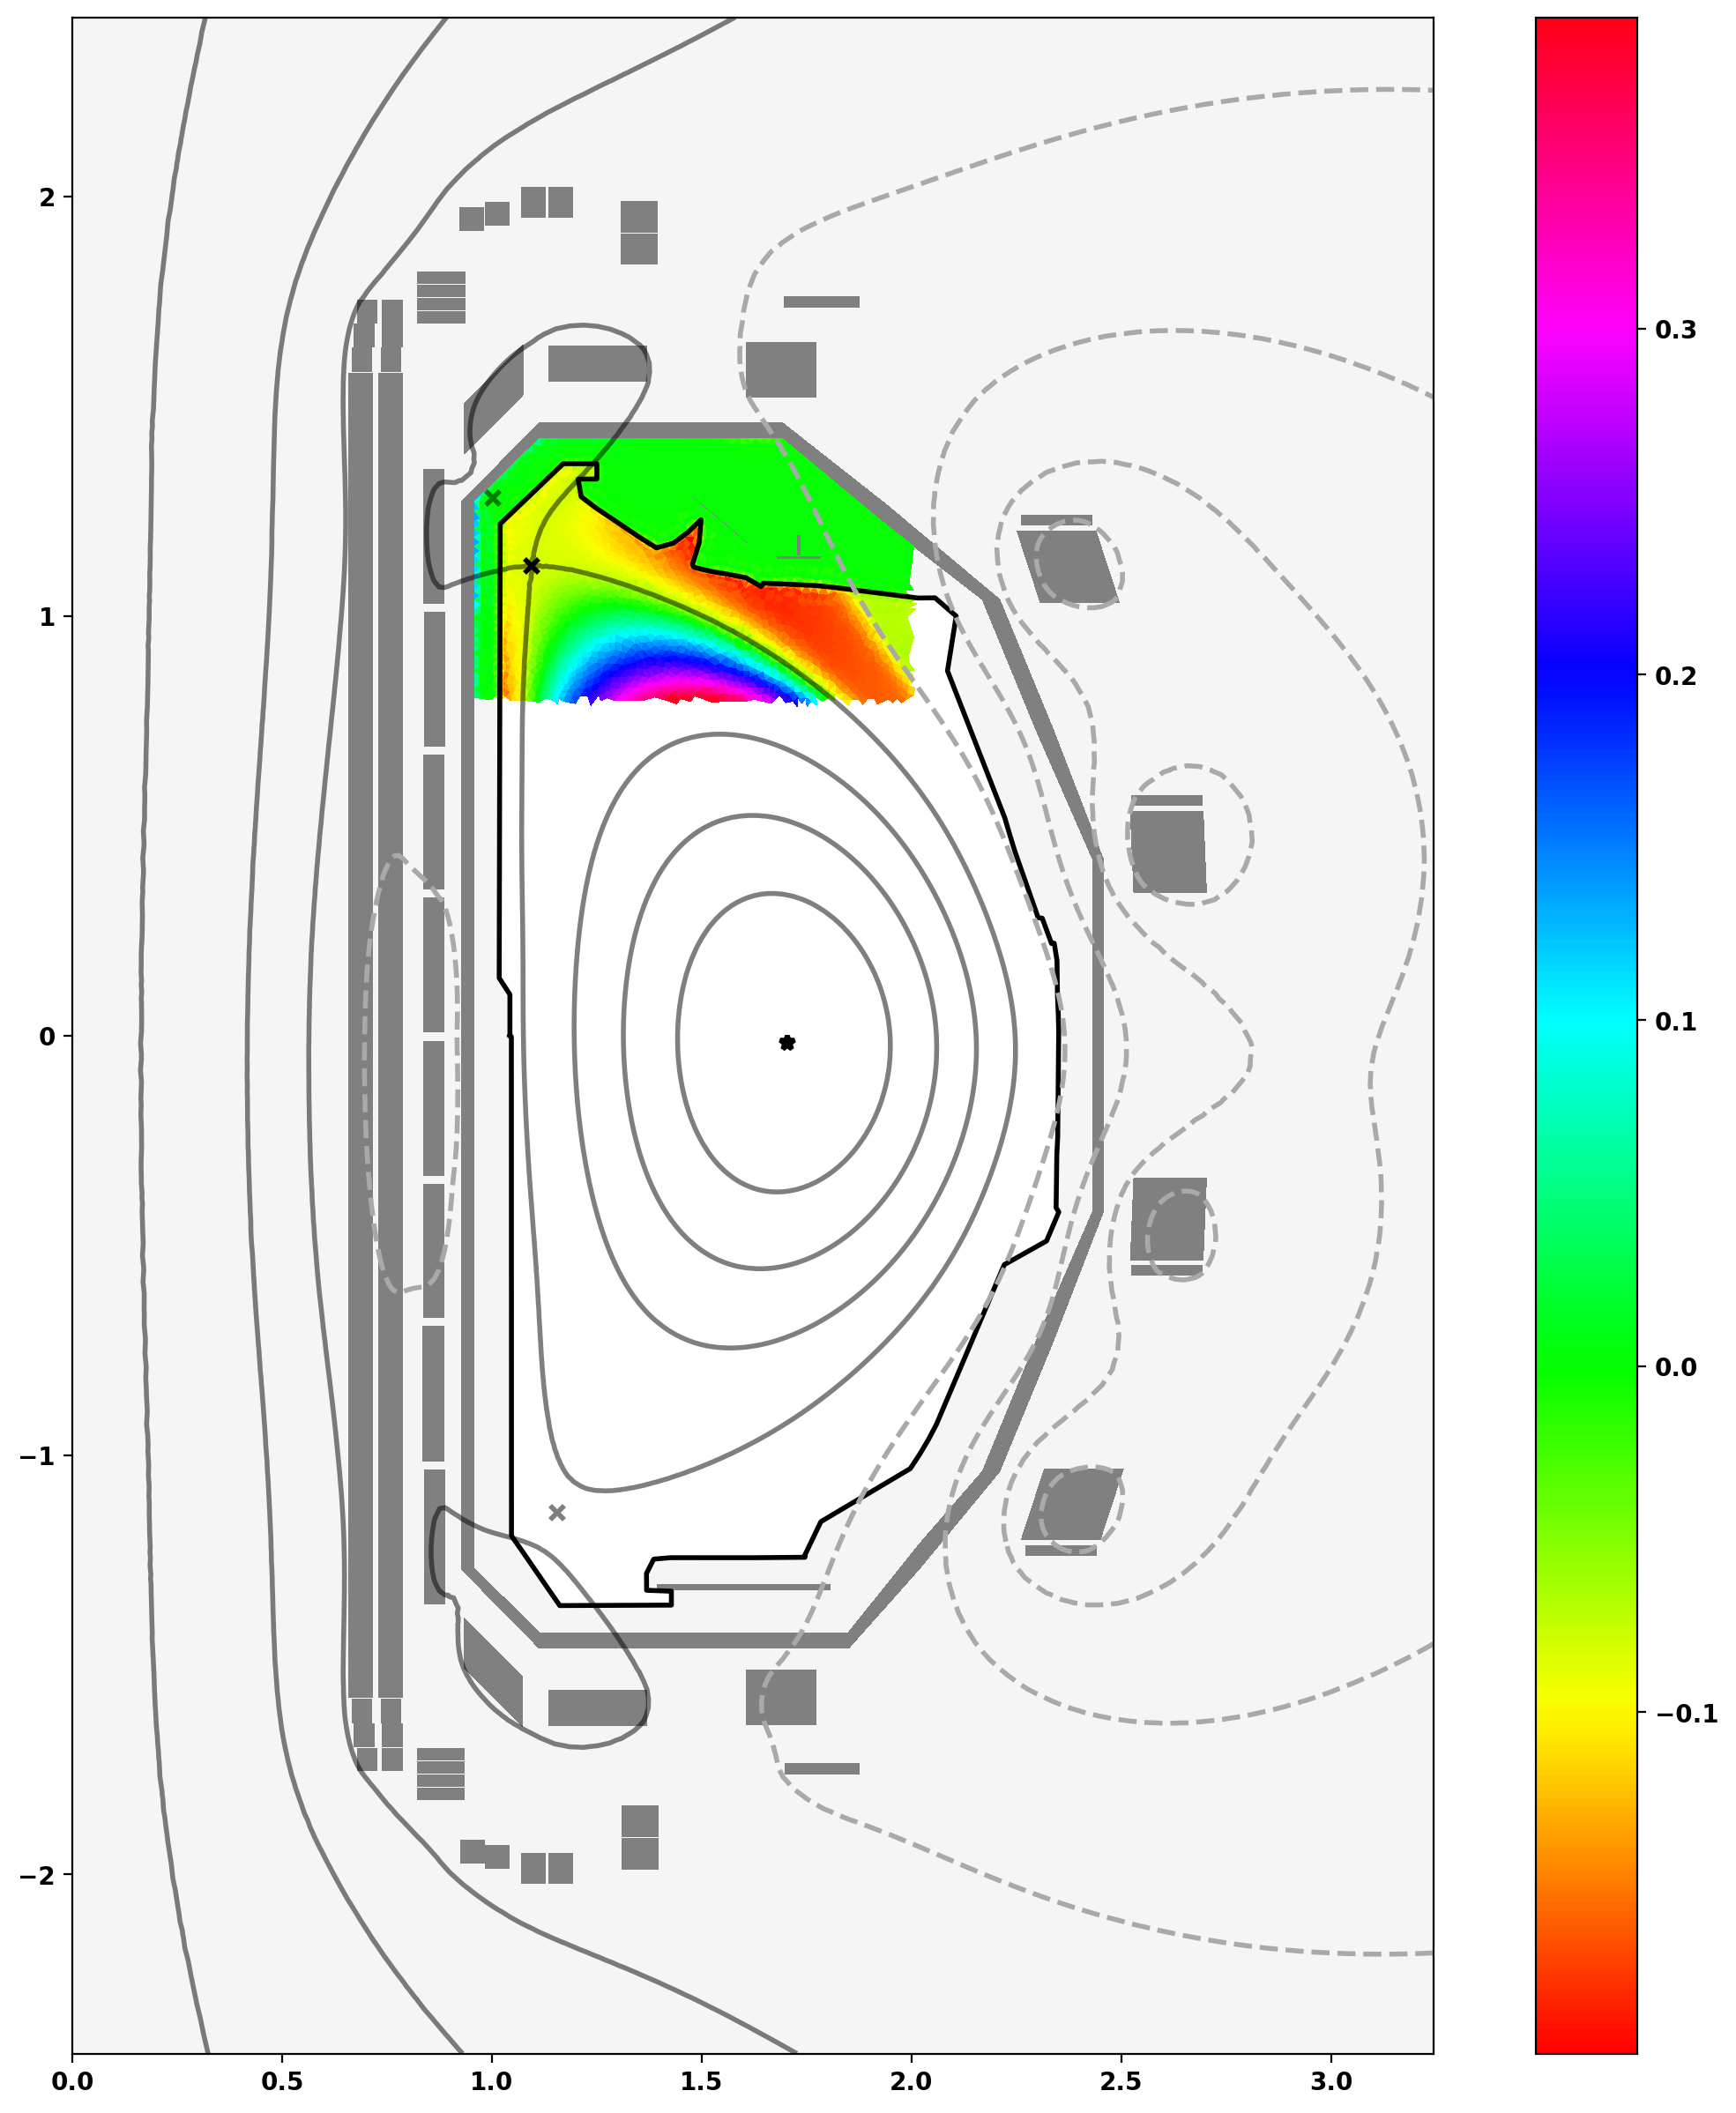

In [20]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1,1, figsize=(15,15))
cmap = ListedColormap([[0.0, 0.0, 0.0, 0.5]])

mygs.plot_machine(fig,ax,coil_clabel=None)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5, plasma_colormap=cmap)
mygs.plot_current_density(fig, ax, window=[0.8, 2.0, 0.8, 2.8], cmap='hsv')

# Show the plot
plt.show()

## Get Strike Points
We can now calculate strike points that occur on the top of the machine using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_strike_points "get_strike_points()". Note that positive SOL currents move the strike point left while negative currents move it right (to see this effect, toggle the f_SOL_sign variable in FF' and P' profiles section).

R=1.0193191059447855
R=1.238840620404512
R=1.2064189166267663
R=1.2057565749387127


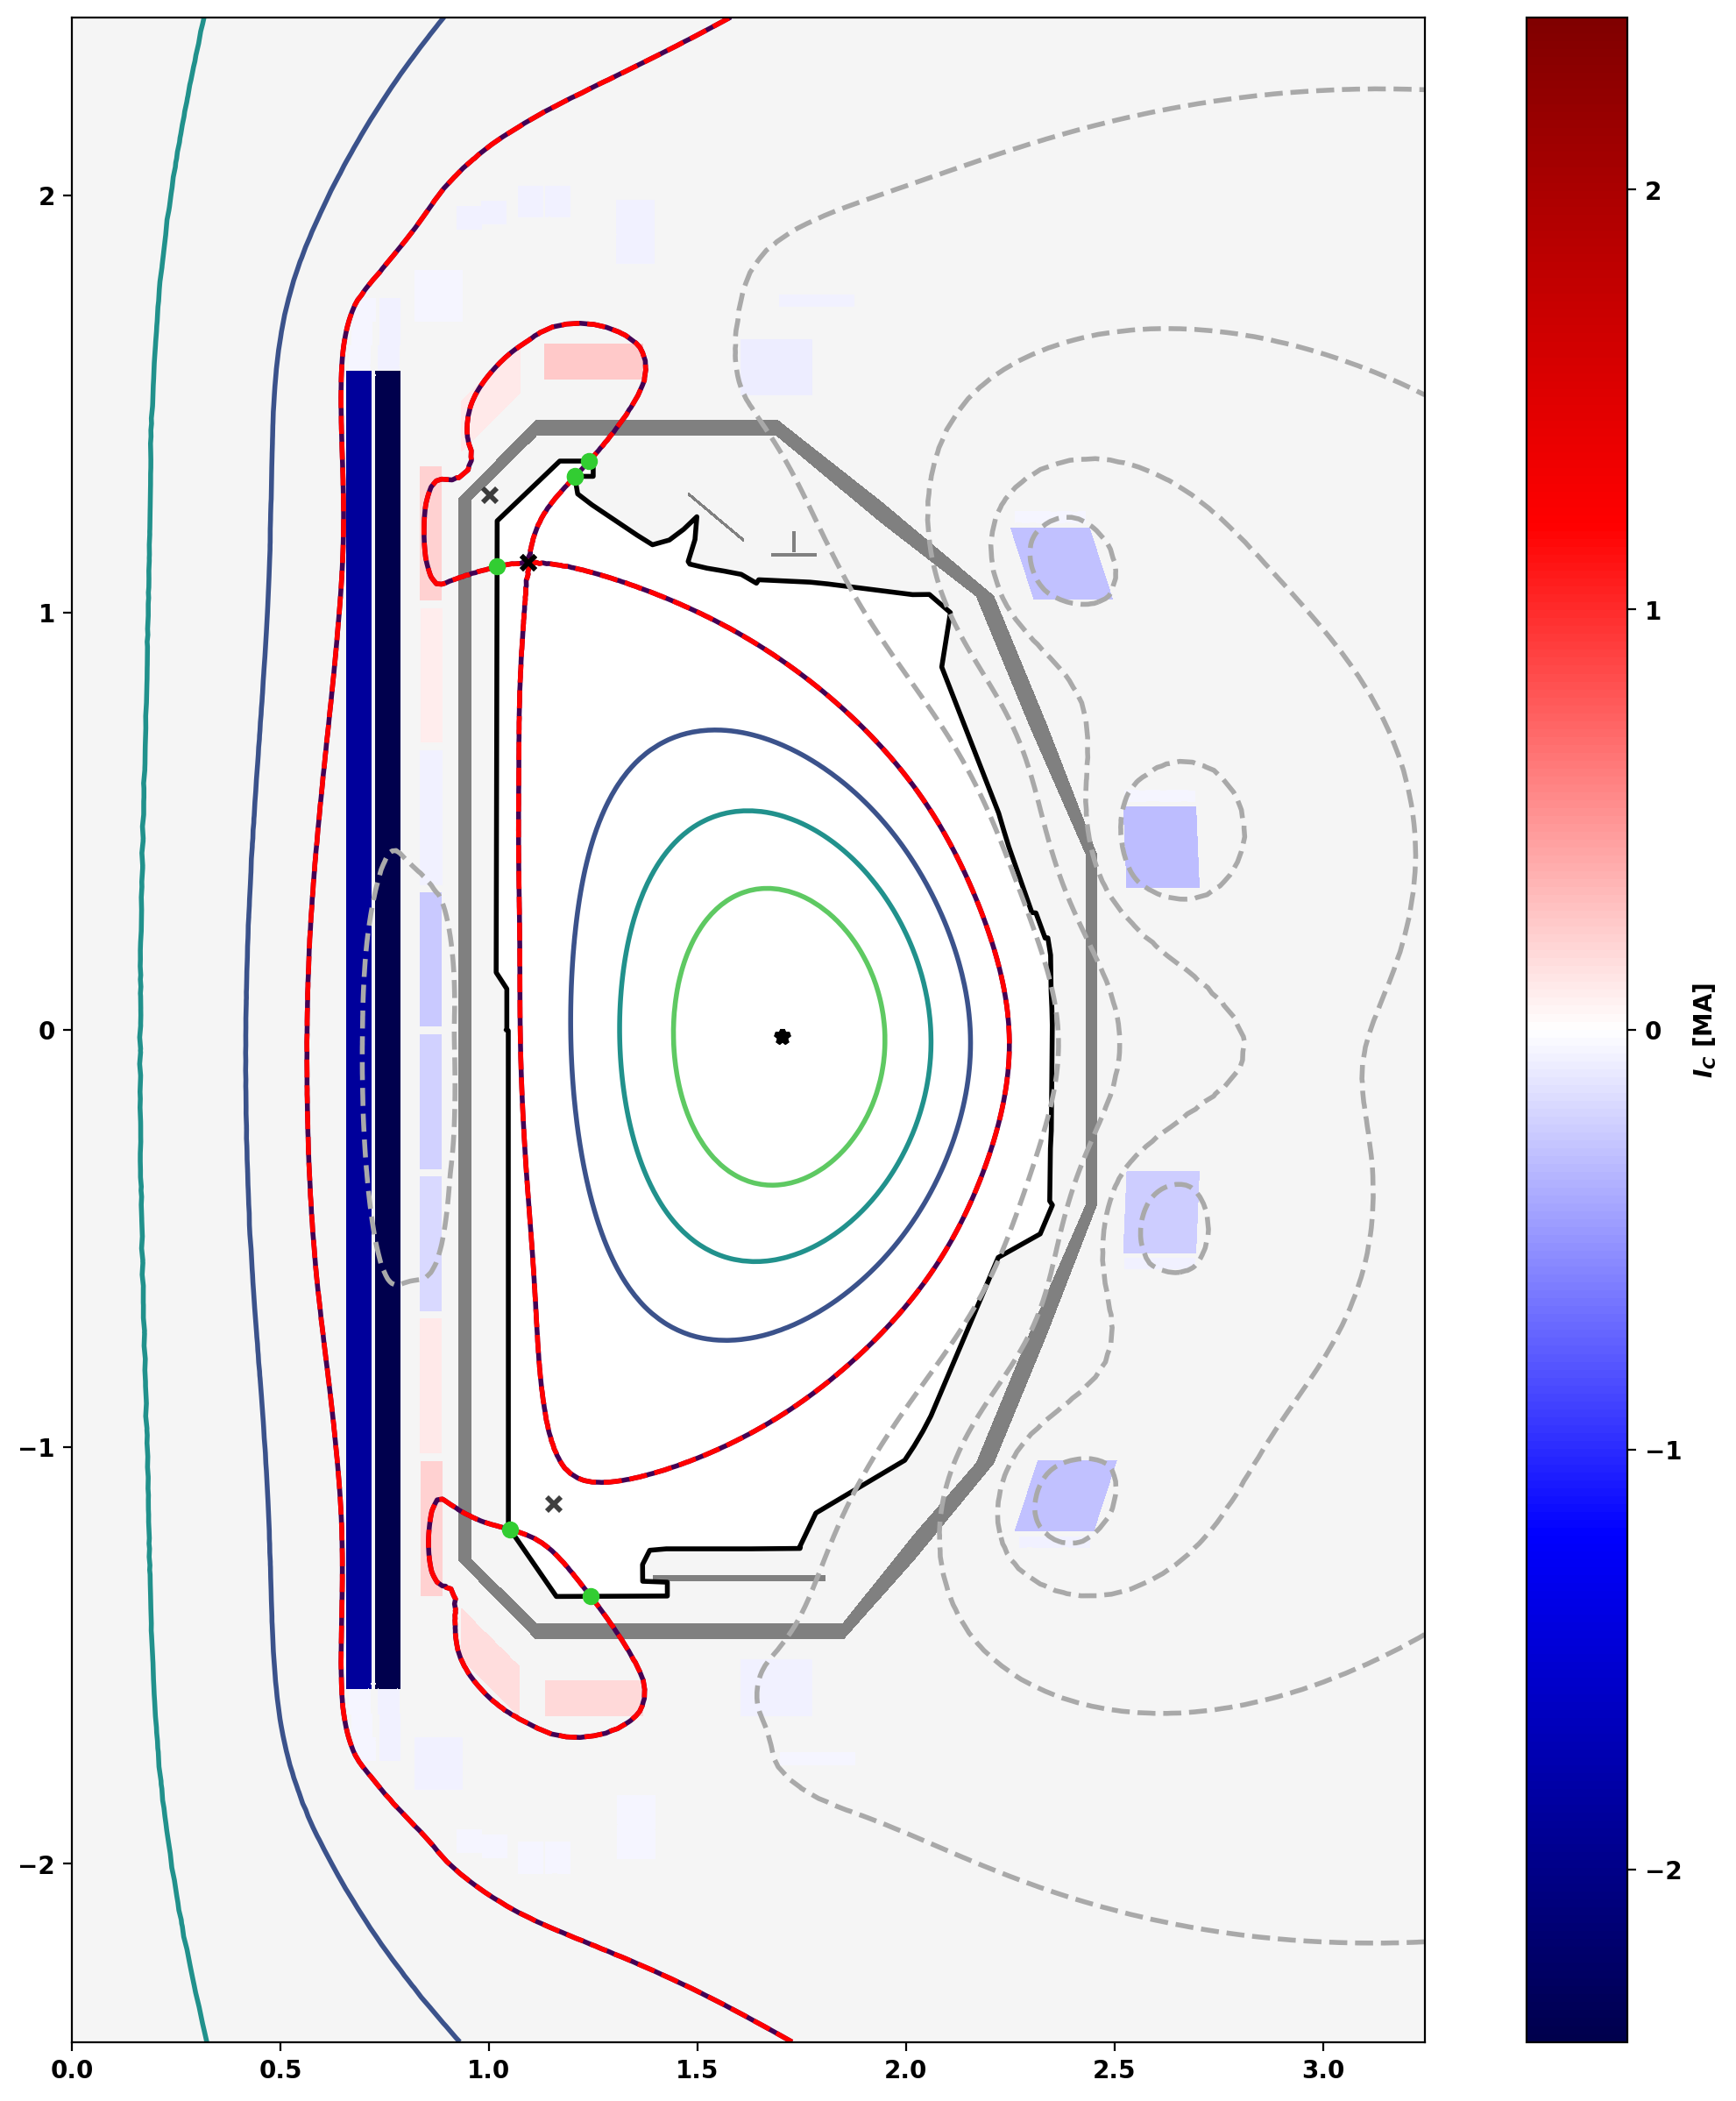

In [21]:
# Plot Psi
fig, ax = plt.subplots(1,1, figsize=(15,15))
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_psi(fig,ax,psi=psi_eq,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')

strike_pts = mygs.get_strike_points()
strike_pts_r = [sp[0] for sp in strike_pts]
strike_pts_z = [sp[1] for sp in strike_pts]
ax.scatter(strike_pts_r, strike_pts_z, color='limegreen', zorder=10)

for i, r in enumerate(strike_pts_r):
    if strike_pts_z[i] > 0:
        print(f'R={r}')

plt.show()